## **Long**
**Mục tiêu:**
- Chuẩn bị dữ liệu & xử lý đặc trưng
- Huấn luyện mô hình baseline: 
    + Linear Algorithms: Logistic Regression 
    + Nonlinear Algorithms: Classi cation and Regression Trees (CART)

In [1]:
# Thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import joblib

# hiển thị đồ thị inline
%matplotlib inline
print("Ready")

Ready


In [2]:
# Load dữ liệu (place train.csv vào cùng thư mục notebook)
import os
print("Working dir:", os.getcwd())

try:
    train = pd.read_csv("train.csv")
    display(train.head())
    print("\nMissing summary:")
    print(train.isnull().sum())
except FileNotFoundError:
    print("Không tìm thấy file train.csv.")

Working dir: e:\KHDL\Khai phá dữ liệu\Challenge_1\sgu25-khaiphadulieu\challenge_1_titanic


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Missing summary:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### 1. Khảo sát nhanh (EDA)
Quan sát các biến, phân phối và mối quan hệ với `Survived`.

Shape: (891, 12)

Các giá trị duy nhất mỗi cột:
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


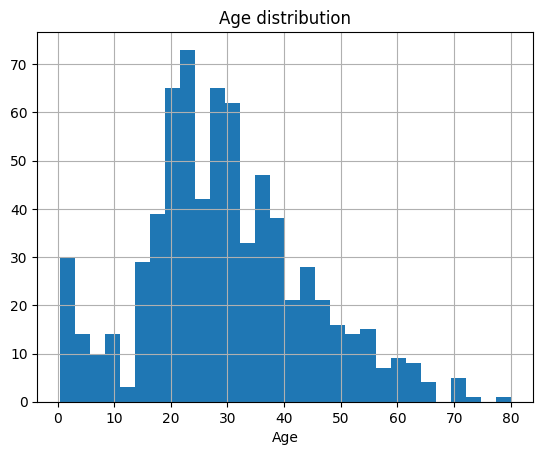

In [3]:
# Nếu train đã được load, thực hiện EDA cơ bản
if 'train' in globals():
    print('Shape:', train.shape)
    print('\nCác giá trị duy nhất mỗi cột:')
    print(train.nunique())
    # Tỷ lệ sống sót theo giới tính và hạng
    display(pd.crosstab(train['Sex'], train['Survived'], normalize='index'))
    display(pd.crosstab(train['Pclass'], train['Survived'], normalize='index'))
    # Biểu đồ tuổi
    train['Age'].hist(bins=30)
    plt.title('Age distribution')
    plt.xlabel('Age')
    plt.show()

### 2. Xử lý đặc trưng (Feature Engineering)
- Điền missing
- Tạo biến mới: `FamilySize`, `IsAlone`, `Title` (tách từ `Name`)
- Loại bỏ các cột ít hữu ích trực tiếp như `Ticket`, `Cabin` (có thể dùng sau này)

In [4]:
if 'train' in globals():
    df = train.copy()
    # Tạo FamilySize và IsAlone
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Extract Title từ Name
    df['Title'] = df['Name'].str.extract(',\s*([^\.]+)\.', expand=False)
    # Gom nhóm các title ít gặp
    df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
    df['Title'] = df['Title'].replace('Mme','Mrs')
    rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(list(rare_titles), 'Rare')

    display(df[['Name','Title']].head())
    display(df[['FamilySize','IsAlone']].head())

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Dell 7480\AppData\Local\Temp\ipykernel_8184\713177670.py:8: SyntaxWarning: invalid escape sequence '\s'
  df['Title'] = df['Name'].str.extract(',\s*([^\.]+)\.', expand=False)


,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


### 3. Chọn features cho baseline
Chúng ta dùng các feature đơn giản: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `FamilySize`, `IsAlone`, `Title`.

In [5]:
if 'train' in globals():
    features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','FamilySize','IsAlone','Title']
    X = df[features].copy()
    y = df['Survived'].copy()
    X.head()

### 4. Pipeline tiền xử lý
- Impute numerical bằng median
- Impute categorical bằng mode
- One-hot encode categorical
- Standardize numeric trước khi đưa vào Logistic Regression

In [6]:
from sklearn.pipeline import make_pipeline

if 'train' in globals():
    numeric_features = ['Age','SibSp','Parch','Fare','FamilySize']
    categorical_features = ['Pclass','Sex','Embarked','IsAlone','Title']

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

In [7]:
if 'train' in globals():
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    # Build pipeline with logistic regression
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000))])
    clf.fit(X_train, y_train)
    print("Done training baseline Logistic Regression")

Done training baseline Logistic Regression


Accuracy: 0.8547486033519553

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179


Confusion matrix:
 [[100  10]
 [ 16  53]]

ROC AUC: 0.8790513833992095


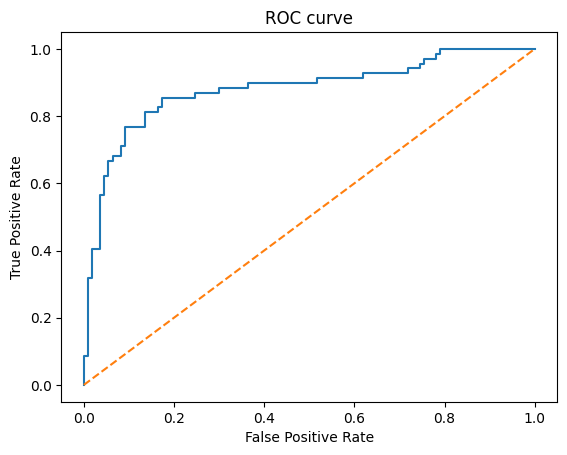

In [8]:
if 'train' in globals():
    y_pred = clf.predict(X_val)
    y_proba = clf.predict_proba(X_val)[:,1]
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("\nClassification report:\n", classification_report(y_val, y_pred))
    print("\nConfusion matrix:\n", confusion_matrix(y_val, y_pred))
    print("\nROC AUC:", roc_auc_score(y_val, y_proba))

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.show()

### 5. Cross-validation (tùy chọn)
Để kiểm tra ổn định, ta có thể chạy cross-val trên pipeline.

In [9]:
if 'train' in globals():
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    print("CV accuracy scores:", scores)
    print("Mean CV accuracy:", scores.mean())

CV accuracy scores: [0.82122905 0.81460674 0.80337079 0.80337079 0.87078652]
Mean CV accuracy: 0.8226727763480008


### 6. Lưu model
Lưu pipeline đã huấn luyện để dùng lại.

In [10]:
if 'train' in globals():
    joblib.dump(clf, 'titanic_logreg_baseline.joblib')
    print("Saved model to titanic_logreg_baseline.joblib")

Saved model to titanic_logreg_baseline.joblib


### 7. Classification and Regression Trees (CART)

In [11]:
# Xác định biến
numeric_features = ['Age','SibSp','Parch','Fare','FamilySize']
categorical_features = ['Pclass','Sex','Embarked','IsAlone','Title']

numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [12]:
# CART model
cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [13]:
# Build pipeline
cart_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', cart_model)
])

# Train
cart_pipeline.fit(X_train, y_train)

# Predict
y_pred = cart_pipeline.predict(X_val)

# Lưu pipeline đã train
joblib.dump(cart_pipeline, "cart_pipeline_model.pkl")
print("Đã lưu model thành công!")

Đã lưu model thành công!
